# Early Stage Diabetes Risk Prediction

**Murlidhar Ravi Geetha Varma — 2025AC05598**
Machine Learning, Assignment 2

Implementing 5 classification models compared on the UCI Early Stage Diabetes Risk Prediction dataset
(ID 529): logistic regression, a decision tree, k-nearest neighbours, Gaussian naive Bayes,
and a random forest. Each is scored on accuracy, AUC, precision, recall, F1 and Matthews
correlation coefficient.

Providing the UCI link below for more details on the dataset:
https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset

In [1]:
import sys
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 9})
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)
ACCENT = "#D85A30"

# To avoid hardcoding of src path and survives the notebook being moved.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").is_dir():
        sys.path.insert(0, str(candidate))
        break

## 1. Exploratory data analysis

### 1.1 Structure and completeness

In [2]:
from src.config import FEATURES, SYMPTOM_FEATURES, TARGET
from src.data import load_data

raw = load_data()

print(f"{raw.shape[0]} instances, {raw.shape[1] - 1} features, 1 target")
print(f"Missing values: {int(raw.isna().sum().sum())}")
print(f"Age range: {raw['Age'].min()}-{raw['Age'].max()}")
raw.head()

520 instances, 16 features, 1 target
Missing values: 0
Age range: 16-90


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


520 instances and 16 features (statisfies assignment minimums of 500 and 12), but with little margin — no feature is dropped anywhere below. 
- 1 feature is continuous (`Age`), 
- 1 is Male/Female (`Gender`), 
- and the remaining 14 are Yes/No symptom indicators. 
- Nothing is missing.

### 1.2 Class distribution

In [3]:
counts = raw[TARGET].value_counts()
baseline = counts.max() / len(raw)

print(counts.to_string())
print(f"\nMajority class: {baseline:.4f} of records")
print(f"Always predicting '{counts.idxmax()}' therefore scores {baseline:.4f} accuracy")

class
Positive    320
Negative    200

Majority class: 0.6154 of records
Always predicting 'Positive' therefore scores 0.6154 accuracy


The classes are uneven. Any accuracy figure below is read against that 61.5% (if model predicts the majority class unconditionally attains that accuracy ;))

### 1.3 Duplicate records

The finding that determines how every model below is evaluated.

In [4]:
duplicated = int(raw.duplicated().sum())
distinct = raw.drop_duplicates()

# If a repeated response profile carried both labels, the repetition would be
# contradictory labelling, which needs a different remedy from leakage.
conflicting = int((raw.groupby(FEATURES, observed=True)[TARGET].nunique() > 1).sum())

print(f"Exact duplicate rows:      {duplicated} of {len(raw)}")
print(f"Distinct response profiles: {len(distinct)}")
print(f"Profiles with both labels:  {conflicting}")
print(f"\nClass balance after deduplication: "
      f"{distinct[TARGET].value_counts(normalize=True).max():.4f} majority")

Exact duplicate rows:      269 of 520
Distinct response profiles: 251
Profiles with both labels:  0

Class balance after deduplication: 0.6892 majority


More than half the records repeat another record exactly, leaving 251 distinct response
profiles. No profile carries both labels, so this is repetition rather than inconsistent
labelling.

The consequence is that a conventional `train_test_split` places identical rows on both sides
of the split. A model that memorises a training row then scores it correctly in the test set
without having generalised at all, and the high accuracies commonly reported on this dataset
partly reflect that. Deduplication before splitting is therefore have to be applied throughout

Deduplication also worsens the imbalance, from 61.5% to 68.9% majority, which raises the
accuracy floor the models must clear.

### 1.4 Feature–target association

In [14]:
pd.Series({c: positive[raw[c].eq("Yes")].mean() for c in SYMPTOM_FEATURES}).sort_values()

Alopecia              0.435754
Itching               0.608696
delayed healing       0.640167
muscle stiffness      0.692308
Obesity               0.693182
weakness              0.714754
Genital thrush        0.715517
visual blurring       0.751073
Polyphagia            0.797468
partial paresis       0.857143
sudden weight loss    0.866359
Irritability          0.873016
Polyuria              0.941860
Polydipsia            0.965665
dtype: float64

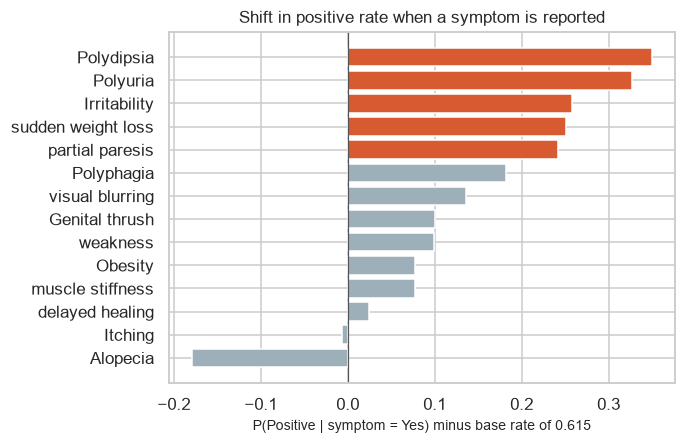

           symptom     shift  positive_rate
        Polydipsia  0.350281       0.965665
          Polyuria  0.326476       0.941860
      Irritability  0.257631       0.873016
sudden weight loss  0.250975       0.866359
   partial paresis  0.241758       0.857143
        Polyphagia  0.182084       0.797468
   visual blurring  0.135688       0.751073
    Genital thrush  0.100133       0.715517
          weakness  0.099369       0.714754
           Obesity  0.077797       0.693182
  muscle stiffness  0.076923       0.692308
   delayed healing  0.024783       0.640167
           Itching -0.006689       0.608696
          Alopecia -0.179630       0.435754


In [24]:
"""
Since symptom features are binary, we can compute the probability of a positive label given that a symptom is reported
This should gives us a measure of association between each symptom and the target.
"""
positive = raw[TARGET].eq("Positive")
base_rate = positive.mean()

sf_mean_ds = pd.Series({c: positive[raw[c].eq("Yes")].mean() for c in SYMPTOM_FEATURES});
association = (
    sf_mean_ds.copy()
    .sub(base_rate)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.barh(association.index, association.values,
        color=[ACCENT if abs(v) > 0.2 else "#9DB0BA" for v in association.values])
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel(f"P(Positive | symptom = Yes) minus base rate of {base_rate:.3f}")
ax.set_title("Shift in positive rate when a symptom is reported")
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "symptom": association.index,
    "shift": association.values,
    "positive_rate": sf_mean_ds[association.index].values
})
print(df.sort_values("positive_rate", ascending=False).reset_index(drop=True).to_string(index=False))

Reporting polyuria or polydipsia moves the positive rate to 0.94 and 0.96 against a base rate
of 0.615. Both are feature presenting symptoms of diabetes, so this is not target leakage —
but it does mean the task is easy, and that a high score is the expected outcome for any
correctly implemented classifier rather than evidence of a strong one.

Alopecia moves the rate downwards, and itching barely moves it at all.

### 1.5 Feature correlation

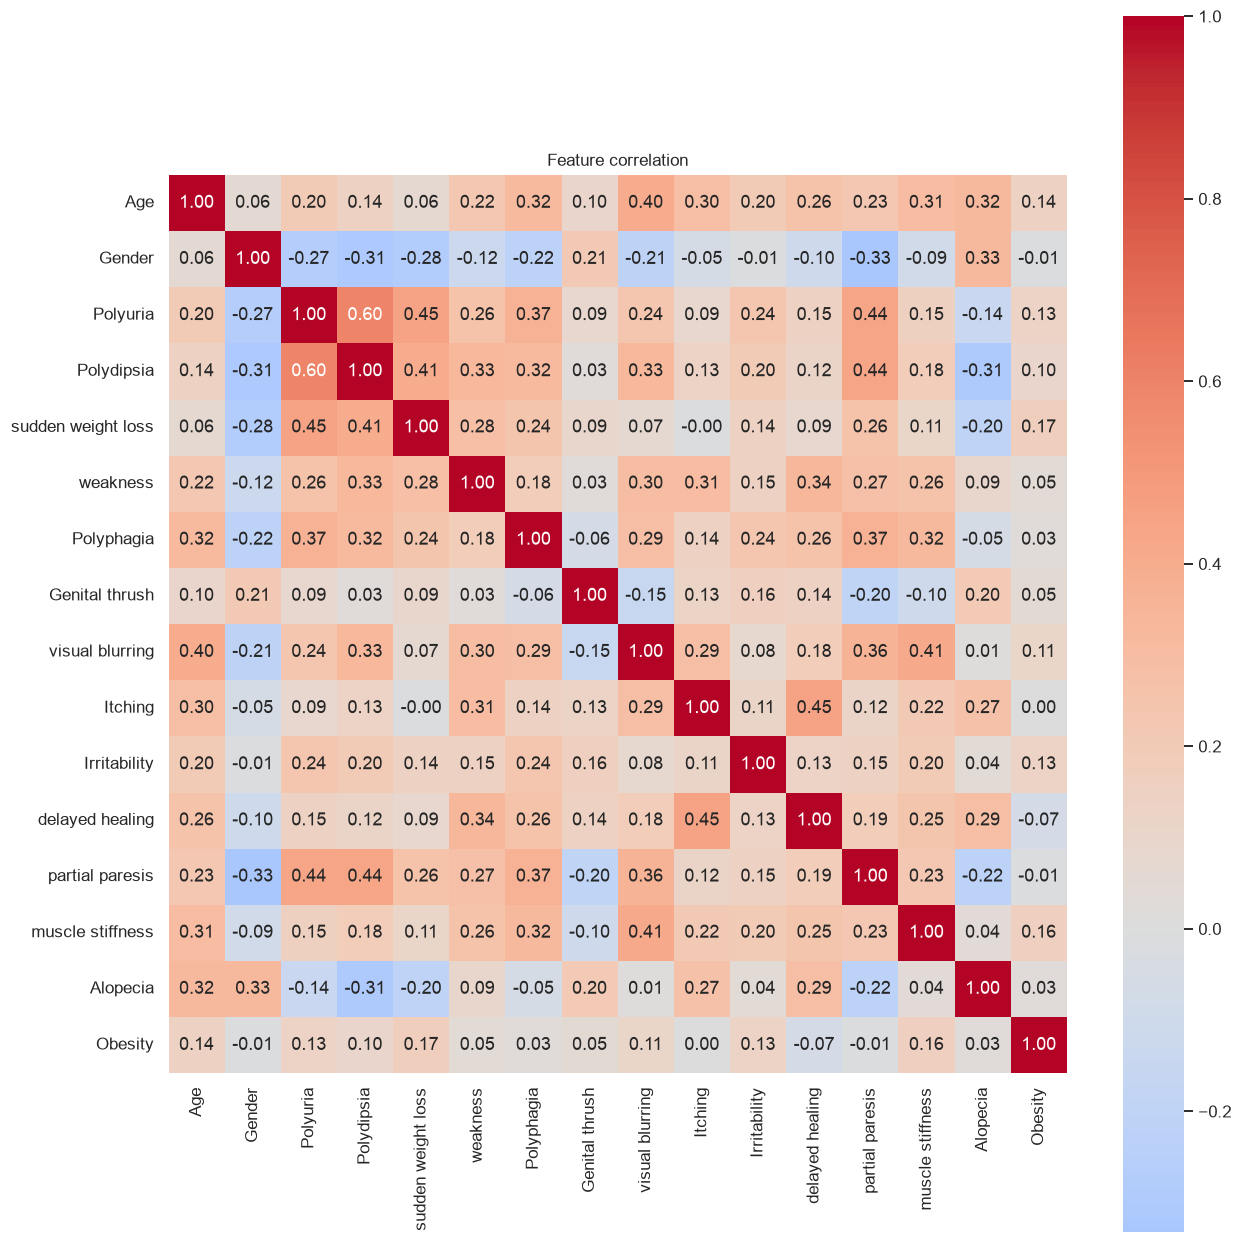

Strongest feature pairs:
Polyuria  Polydipsia            0.598609
Itching   delayed healing       0.453316
Polyuria  sudden weight loss    0.447207


In [29]:
from src.data import encode_features

encoded = encode_features(raw)
correlation = encoded[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

pairs = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool)).stack()
print("Strongest feature pairs:")
print(pairs.abs().sort_values(ascending=False).head(3).to_string())

Polyuria and polydipsia correlate at 0.60, the strongest of the 120 feature pairs and the only
one above 0.5. This bears directly on Naive Bayes, which assumes the features are conditionally
independent given the class, treating the two strongest predictors as independent evidence
counts substantially the same signal twice and produces overconfident posteriors. The prediction
that naive Bayes underperforms is therefore made before any model is fitted.

### 1.6 Key Decisions Taken

| Observation | Consequence |
|---|---|
| 269 of 520 rows are exact duplicates | Deduplicate before splitting; report the conventional split as a contrast |
| Majority class is 61.5%, rising to 68.9% after deduplication | Lead with MCC; quote accuracy against its floor |
| Polyuria and polydipsia nearly determine the outcome | High scores are unremarkable and must be framed as such |
| Polyuria and polydipsia correlate at 0.60 | Naive Bayes' independence assumption is violated |
| `Age` spans 16–90 against fifteen 0/1 columns, and separates the classes weakly | Scale it for the distance-based and penalised models only |